In [3]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [29]:
df_metadata_initalconds = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-cartpole_swingup-noncentered-initial_conditions_seeds_sweep",
    json_file_name="episode_metadata.json",
)

df_initialconds = load_data(
    df_metadata_initalconds,
    episode_file_name="episode_data.pkl",
)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-cartpole_swingup-noncentered-initial_conditions_seeds_sweep: 100%|██████████| 275/275 [00:00<00:00, 15435.71it/s]


Found 275 configurations
Found 275 configurations


100%|██████████| 275/275 [00:00<00:00, 359.28it/s]


In [36]:
np.array(df_initialconds['observations'].iloc[0]).shape

(500, 5)

0      925.854075
1      926.013514
2      924.466638
3      899.737813
4      999.850080
          ...    
270    918.441146
271    925.893925
272    924.078529
273    817.198171
274    923.195635
Name: total_reward, Length: 275, dtype: float64

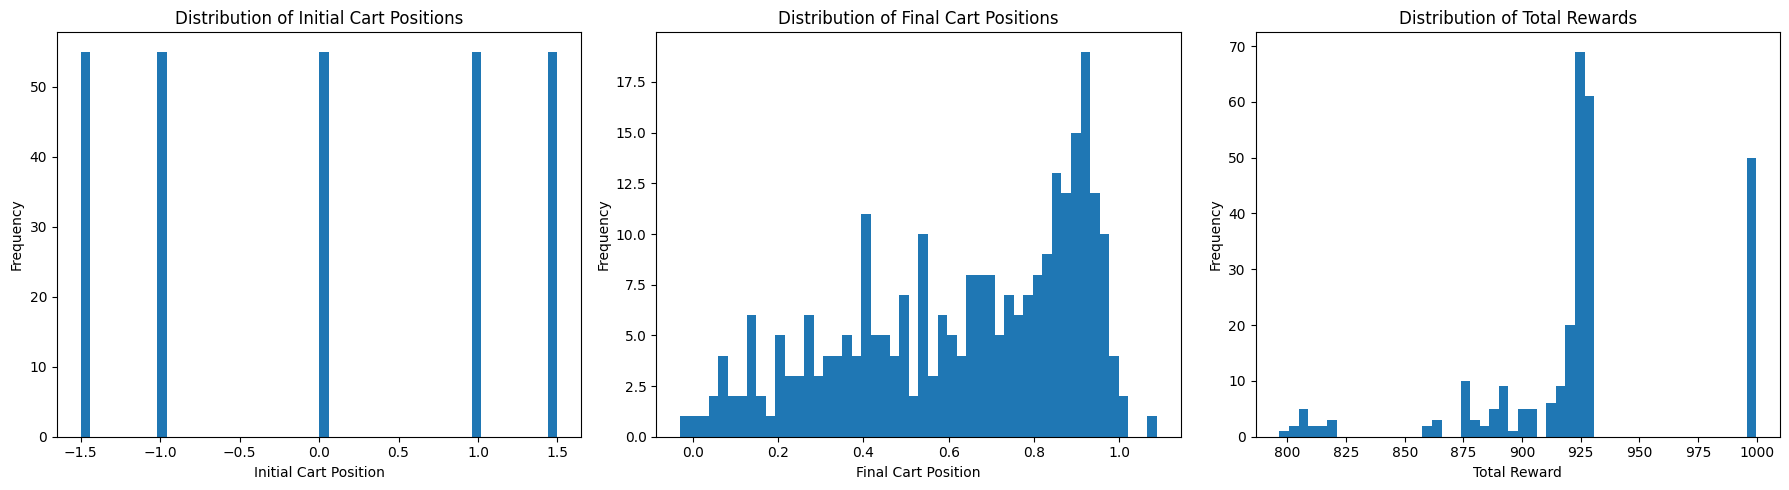

In [40]:
final_positions = df_initialconds['observations'].apply(
    lambda x: np.array(x)[-1, 0])

initial_positions = df_initialconds['observations'].apply(
    lambda x: np.array(x)[0, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(initial_positions, bins=50)
axes[0].set_xlabel('Initial Cart Position')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Initial Cart Positions')

axes[1].hist(final_positions, bins=50)
axes[1].set_xlabel('Final Cart Position')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Final Cart Positions')

axes[2].hist(df_initialconds['total_reward'], bins=50)
axes[2].set_xlabel('Total Reward')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Total Rewards')

plt.tight_layout()
plt.show()


In [44]:
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-control-position-cartpole-swingup-noncentered_sweep",
    json_file_name="episode_metadata.json",
)


Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-control-position-cartpole-swingup-noncentered_sweep: 100%|██████████| 226/226 [00:00<00:00, 818.78it/s]

Found 225 configurations


In [45]:
# df_metadata_probing = df_metadata_probing[
#     df_metadata_probing['config_lasso_alpha'].isin([0.0, np.nan])]
# df_metadata = pd.concat([df_metadata_spsa, df_metadata_probing])
# df_metadata['config_direction_str'] = df_metadata['config_direction_str'].where(
#     pd.notnull(df_metadata['config_direction_str']),
#     np.where(df_metadata.get('config_random', False), 'random', 'spsa'))

# df_metadata = df_metadata[~df_metadata['config_magnitude'].isin([-10., 10.])]

# 8 seeds, 11 alphas (magnitude of directional addition)
df_metadata['config_direction_str'].value_counts()

config_direction_str
random_1    45
random_2    45
actions     45
random_0    45
position    45
Name: count, dtype: int64

In [46]:
df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

Found 225 configurations


100%|██████████| 225/225 [00:00<00:00, 257.44it/s]


In [47]:
df = compute_success(df, starting_step=0, consecutive_steps=200)

In [48]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

In [49]:
df['config_hinge_1_value_degrees'] = np.degrees(df['config_hinge_1_value'])
df['hinge_str'] = df['config_hinge_1_value_degrees'].round(0).astype(str)

for dim in range(5):
    df[f'average_dim_{dim}'] = df['observations'].apply(
        lambda x: np.mean(np.array(x)[:, dim]))

df['total_position_change'] = df['observations'].apply(
    lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

df['total_position_change_midepisode'] = df['observations'].apply(
    lambda x: np.array(x)[-300, 0] - np.array(x)[0, 0])

df['cumulative_abs_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

df['cumulative_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.diff(np.array(x)[:, 0])))

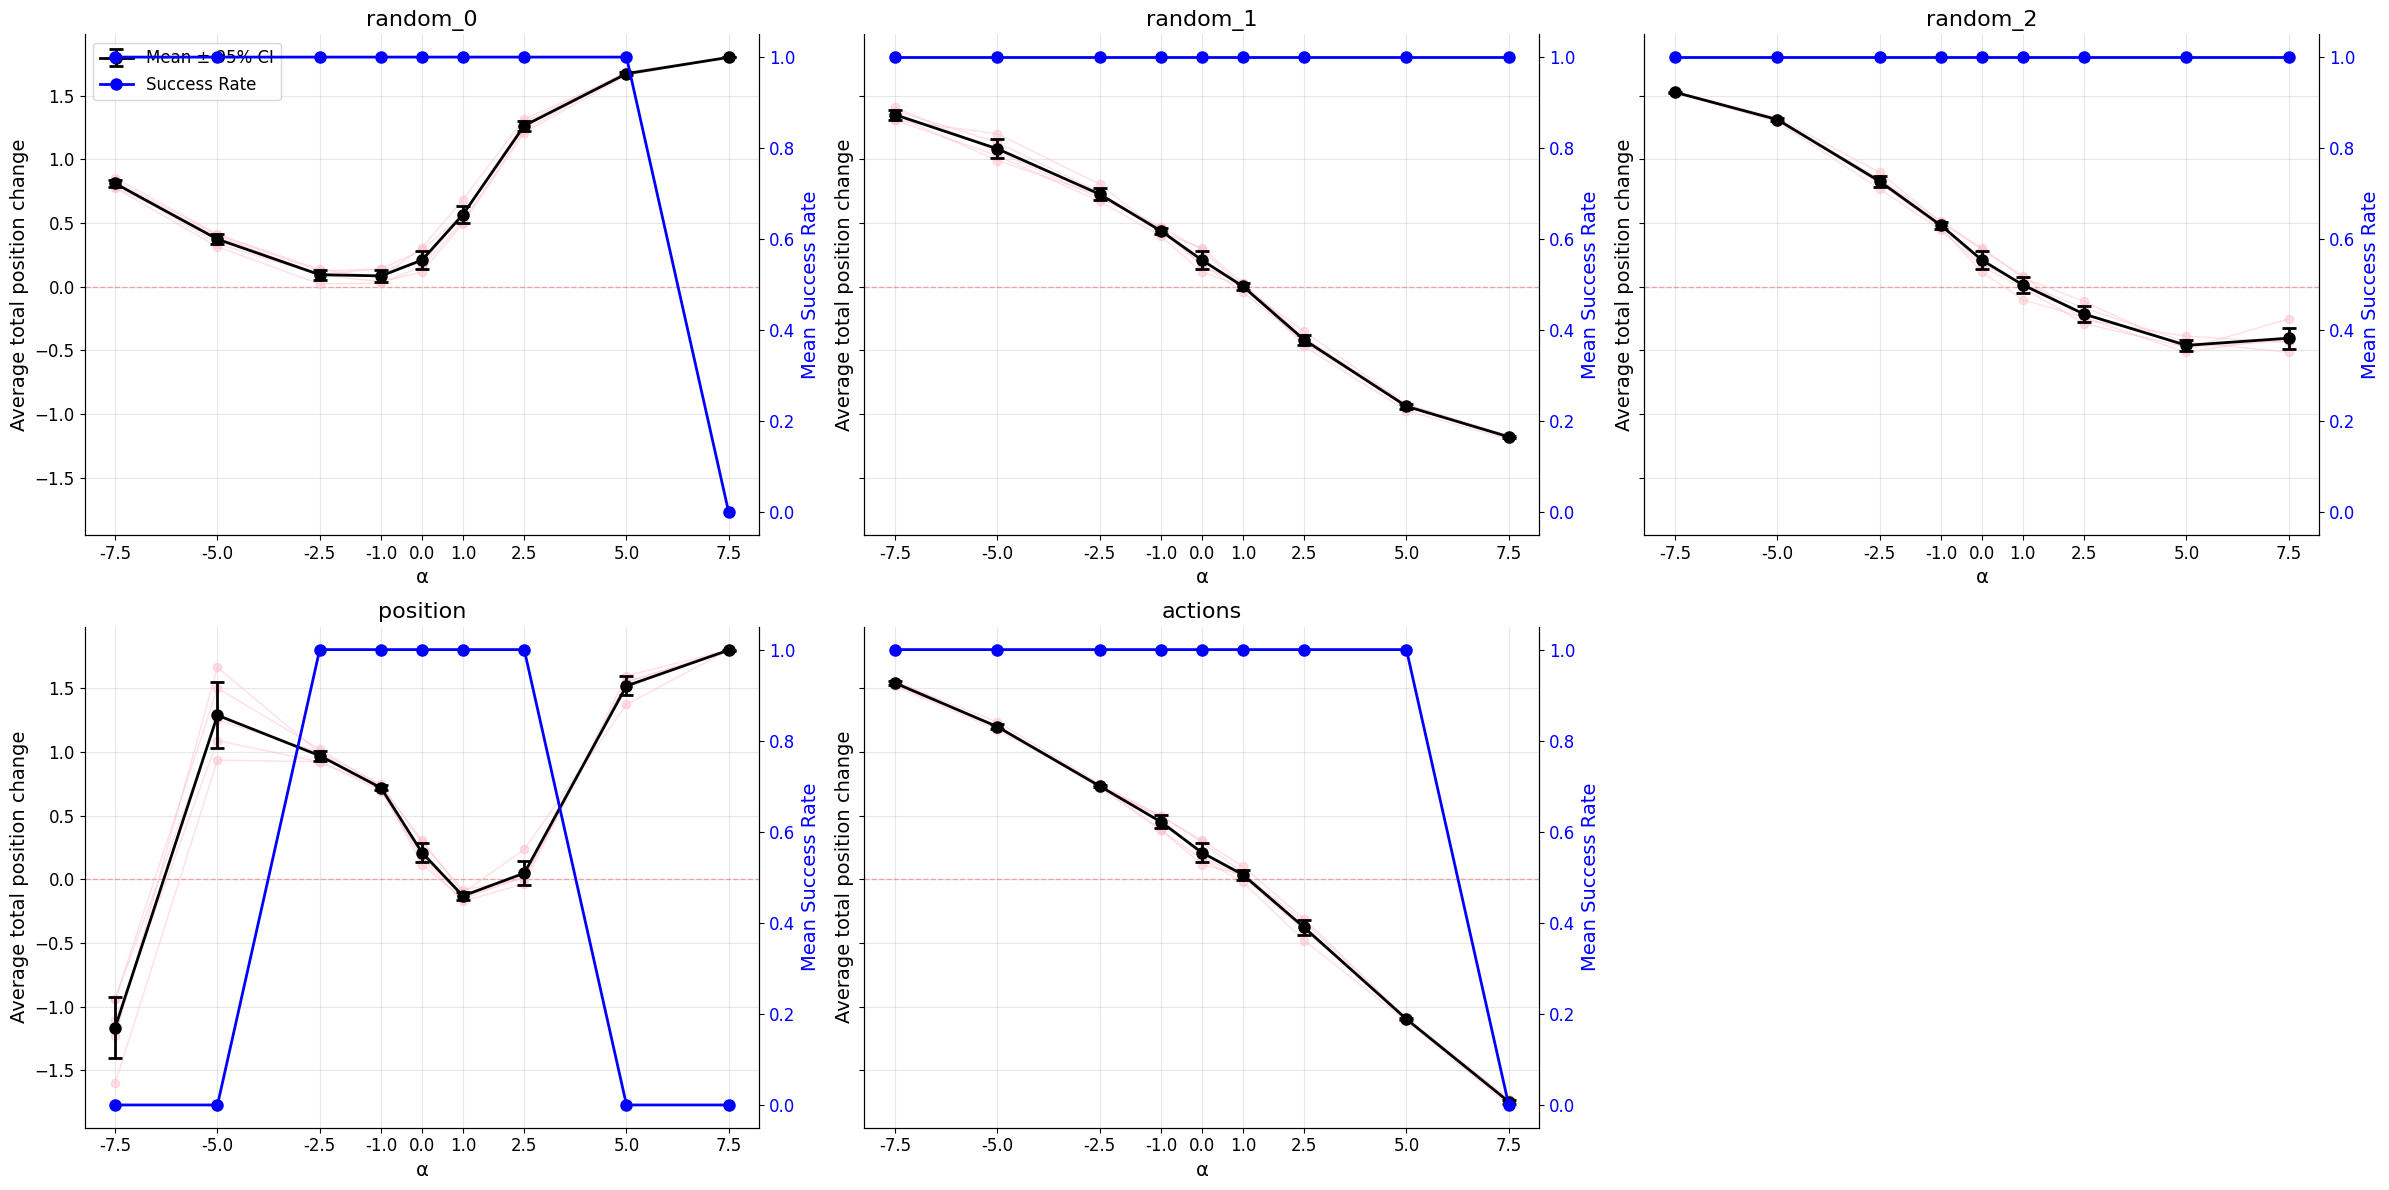

In [51]:
# Get unique direction strings

direction_order = ['random_0', 'random_1', 'random_2', 'position', 'actions']
direction_strs = direction_order
n_directions = len(direction_strs)
y_var = 'total_position_change_midepisode'

# Create subplots: 3 columns, calculate rows needed
n_cols = 3
n_rows = (n_directions + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows), sharey=True)
axes = axes.flatten() if n_directions > 1 else [axes]

for idx, direction_str in enumerate(direction_strs):
    ax1 = axes[idx]

    df_to_plot = df[df['config_direction_str'] == direction_str]

    # Group by alpha
    grouped = df_to_plot.groupby('config_magnitude')

    # Left y-axis:
    ax1.set_xlabel('α', fontsize=14)
    ax1.set_ylabel('Average total position change', fontsize=14)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # Plot one line per seed
    for seed in df_to_plot['config_seed'].unique():
        seed_data = df_to_plot[df_to_plot['config_seed'] == seed].sort_values(
            'config_magnitude')
        ax1.plot(seed_data['config_magnitude'],
                 seed_data[y_var],
                 color='pink',
                 marker='o',
                 alpha=0.5,
                 linewidth=1)

    # Plot mean with error bars (95% CI)
    alphas = []
    means = []
    ci_lower = []
    ci_upper = []

    for alpha, group in grouped:
        alphas.append(alpha)
        mean_val = group[y_var].mean()
        means.append(mean_val)
        std_val = group[y_var].std()
        n = len(group)
        ci = 1.96 * std_val / np.sqrt(n)  # 95% CI
        ci_lower.append(mean_val - ci)
        ci_upper.append(mean_val + ci)

    ax1.errorbar(alphas,
                 means,
                 yerr=[
                     np.array(means) - np.array(ci_lower),
                     np.array(ci_upper) - np.array(means)
                 ],
                 fmt='o-',
                 color='black',
                 linewidth=2,
                 markersize=8,
                 capsize=5,
                 capthick=2,
                 label='Mean ± 95% CI')

    ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.set_xticks(alphas)
    ax1.set_xticklabels([str(a) for a in alphas])
    ax1.grid(True, alpha=0.3)
    #ax1.set_ylim(-1.75, 1.75)

    # Right y-axis: success rate
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Success Rate', fontsize=14, color='blue')
    ax2.set_ylim(-0.05, 1.05)

    # Calculate success rate for each alpha
    success_rates = []
    for alpha, group in grouped:
        success_rate = group['success'].mean()
        success_rates.append(success_rate)

    ax2.plot(alphas,
             success_rates,
             'o-',
             color='blue',
             linewidth=2,
             markersize=8,
             label='Success Rate')
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=12)

    # Title
    ax1.set_title(direction_str, fontsize=16)

    # Legend (only for first plot)
    if idx == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2,
                   labels1 + labels2,
                   loc='upper left',
                   fontsize=12)

# Hide any unused subplots
for idx in range(n_directions, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
sns.despine(top=True, right=False)
plt.show()


/scratch/slurm_tmpdir/job_1593629/ipykernel_3032522/750310589.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


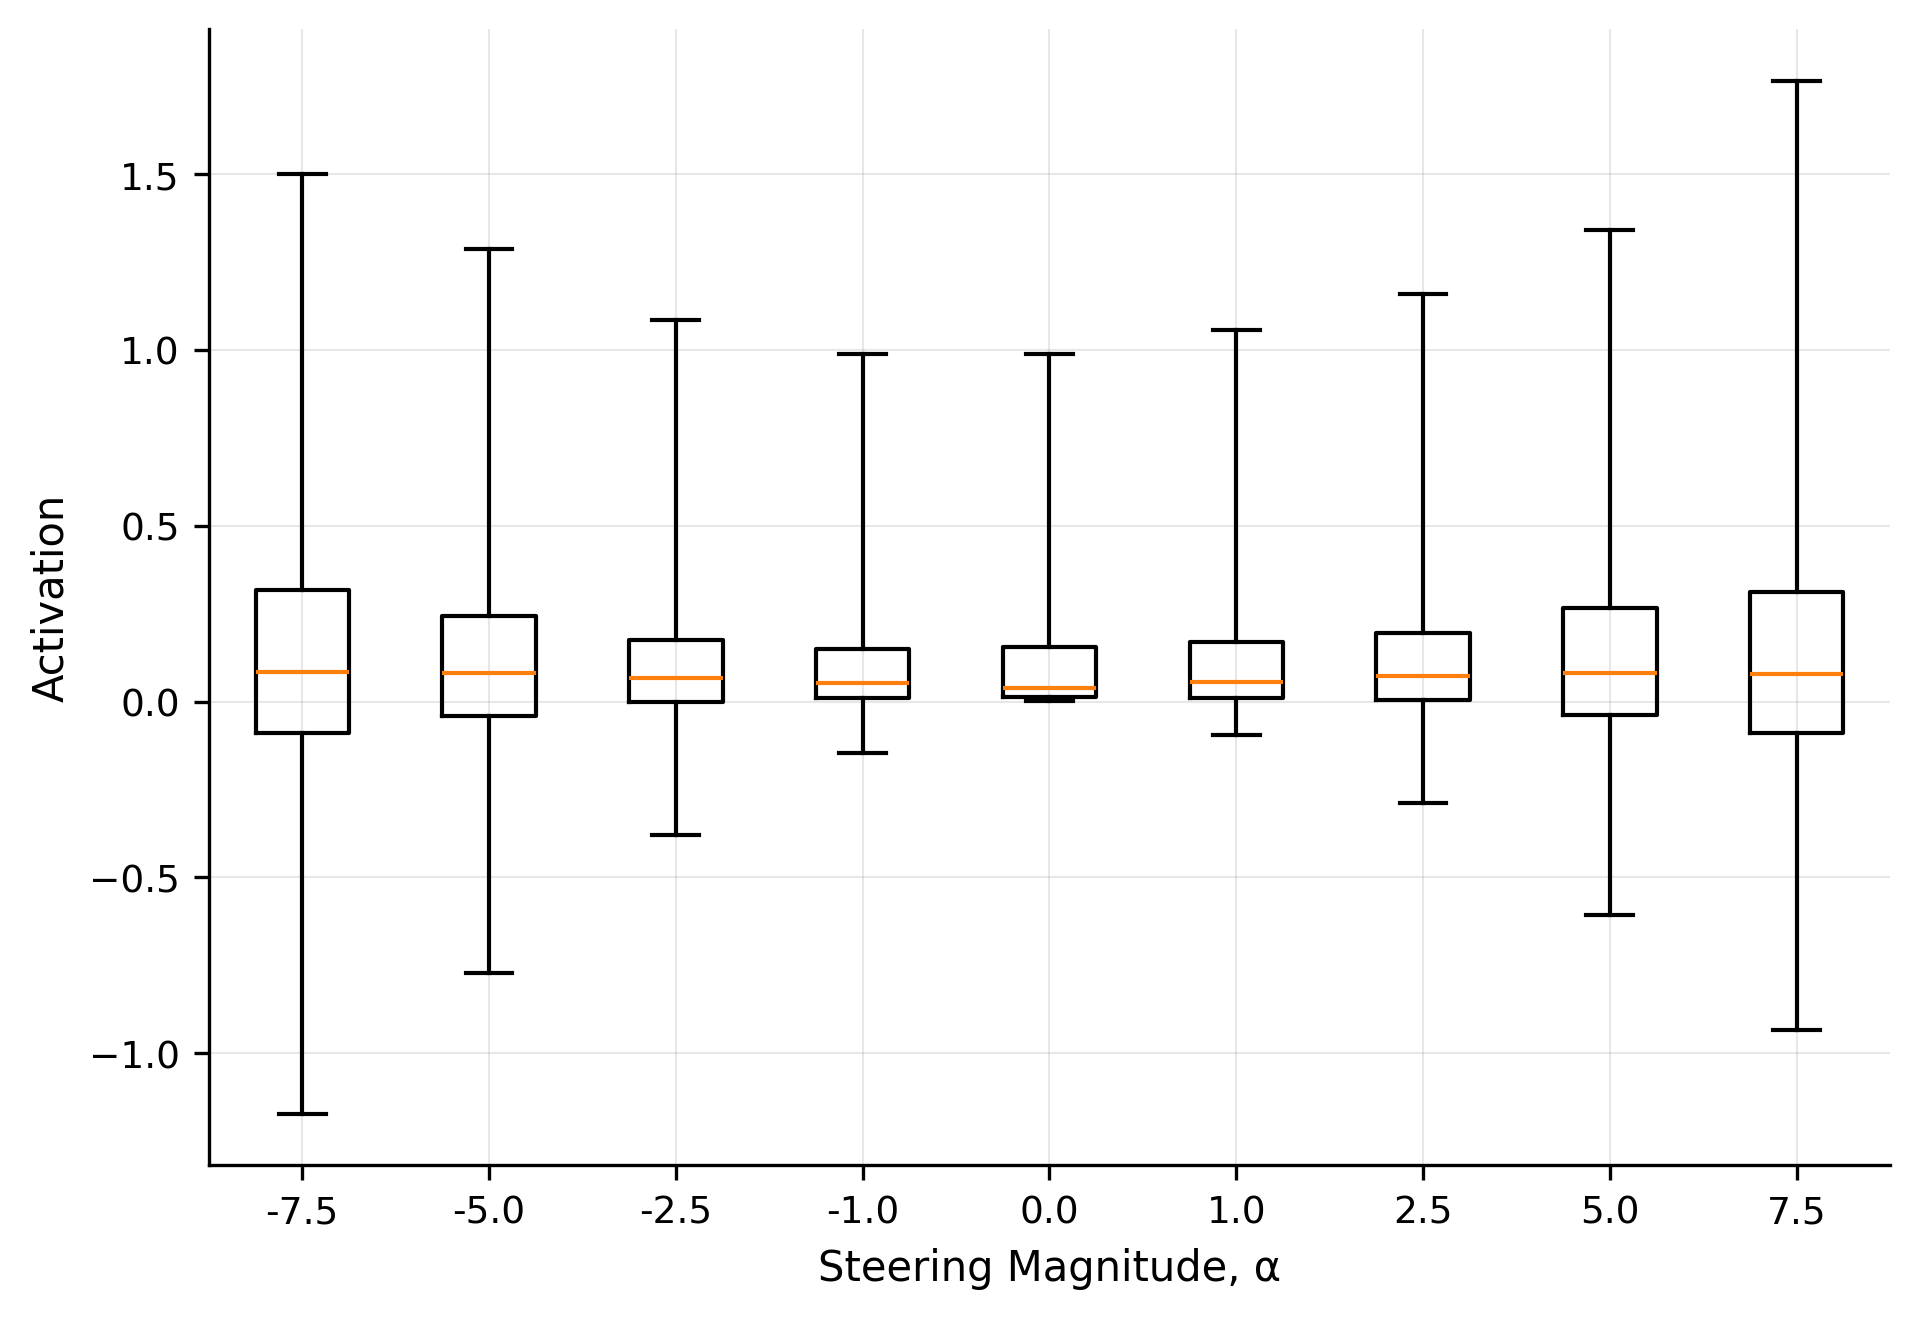

In [47]:
# Plot a boxplot of latent state values by magnitude, one plot for each lasso alpha
lasso_alphas_sorted = sorted(df['config_lasso_alpha'].unique())
magnitudes = sorted(df['config_magnitude'].unique())

df_to_plot = df[df['config_direction_str'] == 'w_action_lasso']
all_latent_values = []

for magnitude in magnitudes:
    # Get all latent states for this magnitude and lasso_alpha
    latent_states = df_to_plot[df_to_plot['config_magnitude'] ==
                               magnitude]['latent_states']

    # Flatten all latent states into a single list
    flattened = []
    for episode_latents in latent_states:
        flattened.extend(episode_latents.flatten())

    all_latent_values.append(flattened)

plt.figure(figsize=(6.5, 4.5), dpi=300)
plt.boxplot(all_latent_values,
            labels=magnitudes,
            showfliers=False,
            whis=[0, 100])
plt.xlabel('Steering Magnitude, α', fontsize=10)
plt.ylabel('Activation', fontsize=10)
plt.tick_params(axis='both', labelsize=9)
plt.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
sns.despine()
plt.show()
